## Predictive Maintenance: Turbofan Jet Engine RUL Estimation

This notebook experiments with a deep learning hybrid network (1D CNN + LSTM)
designed to solve the continuous regression task of predicting Remaining Useful
Life (RUL) using the NASA C-MAPSS FD001 dataset.

### Dataset
- **Source:** NASA Ames Prognostics Center of Excellence (PCoE)
- **Subset:**

  Data Set: FD002
  Train trjectories: 260
  Test trajectories: 259
  Conditions: SIX
  Fault Modes: ONE (HPC Degradation)

- **Task:** Predict the number of remaining operational cycles before engine failure

### Notebook Structure
1. **Data Preprocessing:**  <br> Inspection of raw sensor data and engine cycle distributionn; feature selection, RUL label generation, padding, normalization, and sequence windowing
3. **Model Architecture and Experiments:** <br> 1D CNN + LSTM hybrid defined in `src/models/dynamic_cnn_lstm_nasa.py`

All evaluations include the Nasa-S-Score

   (i) Baseline MSE training <br>
   (ii) Asymmetric MSE loss sweep over beta values <br>
   (iii) Full training with best hyperparameters

4. **Results and Discussion**

### Key Design Decisions
- RUL capped at 125 cycles during training to focus learning on the degradation region
- Constant or low variance features removed (op_setting_3; sensors 16, 18,19, 5, 1)
- Sequence window of 30 cycles fed to the model
- Conservative prediction bias motivated by safety-critical maintenance scheduling
---




In [1]:
import os
import sys
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = "/content/drive/MyDrive/Colab Notebooks/cnn_lstm_conformer_project/"
    os.chdir(base_path)
else:
    base_path = "."

Mounted at /content/drive


In [2]:
# Environment
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1' # ensures deterministic GPU operations


# Main imports
import random
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Main deep learning components
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense, Activation, Flatten, Dropout,
    Conv2D, LSTM, BatchNormalization, MaxPooling2D, Reshape)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# Data processing
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import pickle #for saving and reloading scaler

# Model and evaluation
from src.models import FD002_cnn_lstm_nasa as cnn_lstm
from src.models.losses import make_asymmetric_mse, nasa_s_score

# Seeding
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"System seeded successfully with seed: {seed}")

seed_everything(42)

System seeded successfully with seed: 42


In [3]:
from src.models import dynamic_cnn_lstm_nasa as cnn_lstm


# 1. Data Pre-Processing
## (i) Data inspection and cleaning
Using the elbow method to validate the number of clusters or operating conditions in the data.

In [4]:
file_name = 'nasa_data/6. Turbofan Engine Degradation Simulation Data Set-CMAPSSData'

# Inspect the string represetnation of a few lines line
with open(file_name +'/train_FD002.txt', 'r') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i == 2:
            break

'1 1 34.9983 0.8400 100.0 449.44 555.32 1358.61 1137.23 5.48 8.00 194.64 2222.65 8341.91 1.02 42.02 183.06 2387.72 8048.56 9.3461 0.02 334 2223 100.00 14.73 8.8071  \n'
'1 2 41.9982 0.8408 100.0 445.00 549.90 1353.22 1125.78 3.91 5.71 138.51 2211.57 8303.96 1.02 42.20 130.42 2387.66 8072.30 9.3774 0.02 330 2212 100.00 10.41 6.2665  \n'
'1 3 24.9988 0.6218 60.0 462.54 537.31 1256.76 1047.45 7.05 9.02 175.71 1915.11 8001.42 0.94 36.69 164.22 2028.03 7864.87 10.8941 0.02 309 1915 84.93 14.08 8.6723  \n'


In [5]:
# Define column names
columns = ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

# Load
train = pd.read_csv(file_name+'/train_FD002.txt',
                    sep=r'\s+',
                    header=None,
                    names=columns,
                    index_col=False,
                    engine='python')

test = pd.read_csv(file_name+'/test_FD002.txt',
                   sep=r'\s+',
                   header=None,
                   names=columns,
                   index_col=False,
                   engine='python')

rul = pd.read_csv(file_name+'/RUL_FD002.txt',
                  header=None,
                  names=['RUL'])

# Basic inspection
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("RUL shape:", rul.shape)
print("\n")
print(train.head())
print("\n")
print(train.describe())

Train shape: (53759, 26)
Test shape: (33991, 26)
RUL shape: (259, 1)


   unit  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  \
0     1      1       34.9983        0.8400         100.0    449.44    555.32   
1     1      2       41.9982        0.8408         100.0    445.00    549.90   
2     1      3       24.9988        0.6218          60.0    462.54    537.31   
3     1      4       42.0077        0.8416         100.0    445.00    549.51   
4     1      5       25.0005        0.6203          60.0    462.54    537.07   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1358.61   1137.23      5.48  ...     183.06    2387.72    8048.56   
1   1353.22   1125.78      3.91  ...     130.42    2387.66    8072.30   
2   1256.76   1047.45      7.05  ...     164.22    2028.03    7864.87   
3   1354.03   1126.38      3.91  ...     130.72    2387.61    8068.66   
4   1257.71   1047.93      7.05  ...     164.31    2028.00    7861.23   

   sensor

In [6]:
# We investigate how many cycles each engine had
print(train.groupby('unit')['cycle'].max())

unit
1      149
2      269
3      206
4      235
5      154
      ... 
256    163
257    309
258    143
259    205
260    316
Name: cycle, Length: 260, dtype: int64


We want to identify the number of unique operating conditions and check the standard deviation of the sensors.

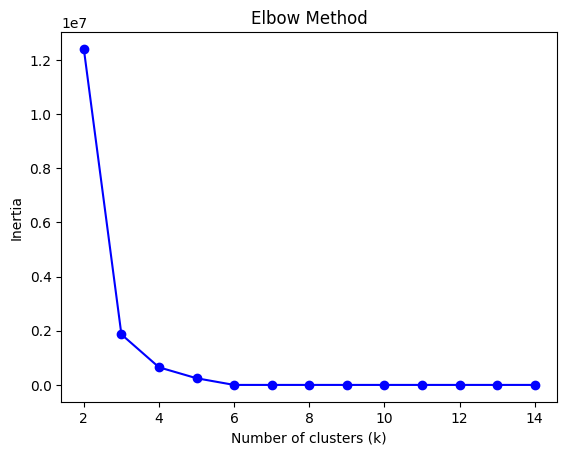

In [7]:
# Perform the elbow method to determine if there are 6 classes using KMeans
inertias = []
k_range = range(2, 15)
setting_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(train[setting_cols])
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [8]:

kmeans = KMeans(n_clusters=6, random_state=42)
train['op_condition'] = kmeans.fit_predict(train[setting_cols])
test['op_condition'] = kmeans.predict(test[setting_cols])  # We use predict not fit_predict

print(f"\nKMeans grouping — unique conditions in train: {train['op_condition'].nunique()}")
print(f"KMeans grouping — unique conditions in test: {test['op_condition'].nunique()}")


KMeans grouping — unique conditions in train: 6
KMeans grouping — unique conditions in test: 6


In [9]:
# Checking the op condition column
print("Sample of op_condition assignments:")
print(train[['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'op_condition']].head(5))

# Number of rows per condition
print("\nRows per condition:")
print(train['op_condition'].value_counts().sort_index())

# Checking std within each condition
print("\nStd within each operating condition:")
feature_cols = [col for col in train.columns
                if col not in ['unit', 'cycle', 'op_condition', 'RUL']]

for condition in range(6):
    subset = train[train['op_condition'] == condition]
    print(f"\nCondition {condition} (n={len(subset)}):")
    print(subset[feature_cols].std().sort_values())

Sample of op_condition assignments:
   unit  cycle  op_setting_1  op_setting_2  op_setting_3  op_condition
0     1      1       34.9983        0.8400         100.0             5
1     1      2       41.9982        0.8408         100.0             0
2     1      3       24.9988        0.6218          60.0             2
3     1      4       42.0077        0.8416         100.0             0
4     1      5       25.0005        0.6203          60.0             2

Rows per condition:
op_condition
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64

Std within each operating condition:

Condition 0 (n=13458):
sensor_1        0.000000e+00
op_setting_3    0.000000e+00
sensor_18       0.000000e+00
sensor_19       0.000000e+00
sensor_16       3.355080e-15
sensor_5        1.234170e-12
op_setting_2    6.371885e-04
sensor_10       1.544363e-03
op_setting_1    2.907350e-03
sensor_6        4.929178e-03
sensor_15       3.751627e-02
sensor_21       6.441301e-02
se

In [ ]:
print(train.columns)

Index(['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'op_condition'],
      dtype='object')


In [10]:

drop_cols = ['op_setting_3', 'sensor_18', 'sensor_19', 'sensor_16', 'sensor_5', 'sensor_1']

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (53759, 21)
Test shape: (33991, 21)


In [ ]:
print(train.columns)

Index(['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'op_condition'],
      dtype='object')


## (ii) Compute RUL labels for the training set
We want to create an RUL column so that every row contains a label. The label will indicate how many cycles are left before failure.

In [11]:
# Compute max cycle per engine (the failure point)
# for each group, find the maximum cycle number
# before reset_index() unit is index, afterwards it becomes a column
# we need unit as a column so we can merge() on the next line and match on unit
max_cycles = train.groupby('unit')['cycle'].max()
max_cycles = max_cycles.reset_index()

max_cycles.columns = ['unit', 'max_cycle']

# Merge back into train and compute RUL
train = train.merge(max_cycles, on='unit')
train['RUL'] = train['max_cycle'] - train['cycle']

# Drop max_cycle column, no longer needed
train = train.drop(columns=['max_cycle'])

print(train[['unit', 'cycle', 'RUL']].head(10))
print("\nMax RUL:", train['RUL'].max())
print("Min RUL:", train['RUL'].min())

   unit  cycle  RUL
0     1      1  148
1     1      2  147
2     1      3  146
3     1      4  145
4     1      5  144
5     1      6  143
6     1      7  142
7     1      8  141
8     1      9  140
9     1     10  139

Max RUL: 377
Min RUL: 0


Investigate the shortest lifespan of the engines. The data shows the minimum lifespan is 128 cycles while the longest lifespan is 378. The model does not need to learn the distinction between early cycles since the engine is healthy.

RUL=125; engine is healthy and not close to failure

RUL=50; starting to degrade

RUL=0 failure

We want to capture the distinction between the later stages of the engine.

In [12]:
# Confirming the min and max of the life cycles in the data
print("Max cycles per engine stats:")
print(max_cycles['max_cycle'].describe())
print("\nshortest life:", max_cycles['max_cycle'].min())
print("longest life:", max_cycles['max_cycle'].max())

Max cycles per engine stats:
count    260.000000
mean     206.765385
std       46.782198
min      128.000000
25%      174.000000
50%      199.000000
75%      230.250000
max      378.000000
Name: max_cycle, dtype: float64

shortest life: 128
longest life: 378


In [13]:
# Cycle values > 125 set to 125
RUL_cap = 125

train['RUL'] = train['RUL'].clip(upper=RUL_cap)

print(train[['unit', 'cycle', 'RUL']].head(10))
print("\nMax RUL:", train['RUL'].max())
print("Min RUL:", train['RUL'].min())

   unit  cycle  RUL
0     1      1  125
1     1      2  125
2     1      3  125
3     1      4  125
4     1      5  125
5     1      6  125
6     1      7  125
7     1      8  125
8     1      9  125
9     1     10  125

Max RUL: 125
Min RUL: 0


## (iii) Normalize the sensor data
Operational settings and sensors should be at the same scale. We only `fit_transform` based on the training data to avoid data leakage. We then `transform` the test data.

# Reloading Scalers, then skip to (iv)

In [14]:
# Important Note: Use this cell when reloading the scalers
with open('weights/FD002_weights/scalers_FD002.pkl', 'rb') as f:
    scalers = pickle.load(f)

feature_cols = [col for col in train.columns
                if col not in ['unit', 'cycle', 'RUL', 'op_condition']]

# Apply saved scalers to data
for condition in range(6):
    mask = train['op_condition'] == condition
    train.loc[mask, feature_cols] = scalers[condition].transform(  # Note: transform()
        train.loc[mask, feature_cols])

for condition in range(6):
    mask = test['op_condition'] == condition
    test.loc[mask, feature_cols] = scalers[condition].transform(  # Note: transform()
        test.loc[mask, feature_cols])

/tmp/ipykernel_7634/1528029006.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.33333333 0.22222222 0.33333333 ... 0.77777778 0.77777778 0.77777778]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train.loc[mask, feature_cols] = scalers[condition].transform(  # Note: transform()
/tmp/ipykernel_7634/1528029006.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.55555556 0.33333333 0.33333333 ... 0.55555556 0.44444444 0.44444444]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[mask, feature_cols] = scalers[condition].transform(  # Note: transform()


In [15]:
print(train[feature_cols].describe())

       op_setting_1  op_setting_2      sensor_2      sensor_3      sensor_4  \
count  53759.000000  53759.000000  53759.000000  53759.000000  53759.000000   
mean       0.500482      0.248679      0.480626      0.467764      0.455308   
std        0.289489      0.322896      0.146495      0.139378      0.155711   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.250000      0.000000      0.377419      0.369978      0.344172   
50%        0.500000      0.000000      0.472561      0.459897      0.441108   
75%        0.750000      0.500000      0.576547      0.557967      0.553396   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

           sensor_6      sensor_7      sensor_8      sensor_9     sensor_10  \
count  53759.000000  53759.000000  53759.000000  53759.000000  53759.000000   
mean       0.454984      0.543858      0.289706      0.207747      0.426980   
std        0.440613      0.137460      0.147834    

# Applying normalization (first run)

In [ ]:
# Important Note: Run this cell when running the notebook for the first time
feature_cols = [col for col in train.columns
                if col not in ['unit', 'cycle', 'RUL', 'op_condition']]

scalers = {}  # a dictionary of 6 scalers, one per condition

for condition in range(6):
    scaler = MinMaxScaler()
    mask = train['op_condition'] == condition
    train.loc[mask, feature_cols] = scaler.fit_transform( # Note: fit_transform()
        train.loc[mask, feature_cols])
    scalers[condition] = scaler  # save for test set

# Apply to test set using the same scalers
for condition in range(6):
    mask = test['op_condition'] == condition
    test.loc[mask, feature_cols] = scalers[condition].transform( # Note: transform()
        test.loc[mask, feature_cols])

print("Normalization complete")
print(train[feature_cols].describe())

/tmp/ipykernel_9717/668294426.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.33333333 0.22222222 0.33333333 ... 0.77777778 0.77777778 0.77777778]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train.loc[mask, feature_cols] = scaler.fit_transform(
/tmp/ipykernel_9717/668294426.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.55555556 0.33333333 0.33333333 ... 0.55555556 0.44444444 0.44444444]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[mask, feature_cols] = scalers[condition].transform(


Normalization complete
       op_setting_1  op_setting_2      sensor_2      sensor_3      sensor_4  \
count  53759.000000  53759.000000  53759.000000  53759.000000  53759.000000   
mean       0.500482      0.248679      0.480626      0.467764      0.455308   
std        0.289489      0.322896      0.146495      0.139378      0.155711   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.250000      0.000000      0.377419      0.369978      0.344172   
50%        0.500000      0.000000      0.472561      0.459897      0.441108   
75%        0.750000      0.500000      0.576547      0.557967      0.553396   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

           sensor_6      sensor_7      sensor_8      sensor_9     sensor_10  \
count  53759.000000  53759.000000  53759.000000  53759.000000  53759.000000   
mean       0.454984      0.543858      0.289706      0.207747      0.426980   
std        0.440613      0.1

In [ ]:
# Important Note: Run this cell only during the first run of the notebook
# Save the scalar
# Remember the min and max values of each feature column from the training set
# Allows us to preprocess the new data exactly the same way as the training data.
with open('weights/FD002_weights/scalers_FD002.pkl', 'wb') as f:
    pickle.dump(scalers, f)

## (iv) Windowing
We create sequences so that the model can learn temporal patterns.
Formula: `num_cycles_per_engine - window_size + 1`

If engine has 192 cycles, `window_size = 30`, and `sequences = 192 - 30 + 1 = 163`  
Each sequence has `shape (window_size, num_features)`. So the full training set across `num_engines` will have `shape (total_sequences, window_size, num_features)`.


In [16]:
def create_sequences(data, sequence_length=30):
    X, y = [], []

    for unit in data['unit'].unique():
        unit_data = data[data['unit'] == unit]
        features = unit_data[feature_cols].values
        rul = unit_data['RUL'].values

        if len(features) < sequence_length:
            pad_length = sequence_length - len(features)
            padding = np.repeat(features[0:1], pad_length, axis=0)
            features = np.vstack([padding, features])
            rul = np.pad(rul, (pad_length, 0), mode='edge')

        for i in range(len(features) - sequence_length + 1):
            X.append(features[i:i + sequence_length])
            y.append(rul[i + sequence_length - 1])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train, sequence_length=30)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (46219, 30, 18)
y_train shape: (46219,)


In [17]:
# Checking if any engines have less than 30 cycles in either test or train data
print(f"Min cycles in train: {train.groupby('unit')['cycle'].max().min()}")
print(f"Min cycles in test: {test.groupby('unit')['cycle'].max().min()}")

Min cycles in train: 128
Min cycles in test: 21


In [18]:
# Checking the test data cycles to see how many are below 30
print(test.groupby('unit')['cycle'].max().sort_values().head(10))

unit
83     21
59     22
28     23
201    25
223    29
122    29
205    31
218    33
165    35
249    36
Name: cycle, dtype: int64


In [19]:
# Pad the test data ...
def create_test_sequences(data, sequence_length=30):
    X = []

    for unit in data['unit'].unique():
        unit_data = data[data['unit'] == unit]
        features = unit_data[feature_cols].values

        if len(features) < sequence_length:
            # Pad by repeating the first row
            pad_length = sequence_length - len(features)
            padding = np.repeat(features[0:1], pad_length, axis=0)
            features = np.vstack([padding, features])

        X.append(features[-sequence_length:])

    return np.array(X)


X_test = create_test_sequences(test, sequence_length=30)
y_test = rul['RUL'].values

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (259, 30, 18)
y_test shape: (259,)


In [20]:
print(len(feature_cols))
print(train.columns)

18
Index(['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'op_condition', 'RUL'],
      dtype='object')


In [21]:
print(feature_cols)

['op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


# 2. Experiment using CNN-LSTM hybrid model and varying loss functions and their hyper parameters
## (i) Baseline symmetric MSE with epoch=50

In [22]:
import importlib
from src.models import dynamic_cnn_lstm_nasa as cnn_lstm
importlib.reload(cnn_lstm)


<module 'src.models.dynamic_cnn_lstm_nasa' from '/content/drive/MyDrive/Colab Notebooks/cnn_lstm_conformer_project/src/models/dynamic_cnn_lstm_nasa.py'>

In [ ]:
learning_rate = 1e-3
model = cnn_lstm.CNN_LSTM(input_shape=(30,18))

model.compile(loss='mse',
                  optimizer=optimizers.Adam(learning_rate),
                  metrics=['mse'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Saving the best model wights and model architecture from training
checkpoint = ModelCheckpoint(
    filepath='weights/best_baseline_initial_model_fd002.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
epochs = 50
batch_size = 32

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 126s 103ms/step - loss: 6671.4570 - mse: 6671.4570 - val_loss: 5560.3320 - val_mse: 5560.3320
Epoch 2/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 119s 103ms/step - loss: 4987.6807 - mse: 4987.6807 - val_loss: 4261.3657 - val_mse: 4261.3657
Epoch 3/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 123s 106ms/step - loss: 3842.3726 - mse: 3842.3726 - val_loss: 3300.1721 - val_mse: 3300.1721
Epoch 4/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 119s 103ms/step - loss: 3000.7285 - mse: 3000.7285 - val_loss: 2611.7173 - val_mse: 2611.7173
Epoch 5/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 119s 103ms/step - loss: 2348.1873 - mse: 2348.1873 - val_loss: 1801.0387 - val_mse: 1801.0387
Epoch 6/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 118s 102ms/step - loss: 1669.3157 - mse: 1669.3157 - val_loss: 1422.9189 - val_mse: 1422.9189
Epoch 7/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 117s 101ms/step - loss: 1265.5742 - mse: 1265.5742 - val_loss: 974.1783 - val_mse: 974.1783
Epoch 8/50
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 144s 103

# Reloading the Model

In [ ]:
# Important Note: Run this cell when reloading the model
learning_rate = 1e-3

model = cnn_lstm.CNN_LSTM(input_shape=(30,18))

# Loading the weights directly into the structure and compile
model.load_weights('weights/best_baseline_initial_model_fd002.keras')
model.compile(loss='mse',
                  optimizer=optimizers.Adam(learning_rate),
                  metrics=['mse'])



In [ ]:
# Evaluate on test set
test_loss = model.evaluate(X_test, y_test, verbose=1)
print(f"Test MSE: {test_loss[1]:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss[1]):.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 776.5938 - mse: 776.5938
Test MSE: 776.5938
Test RMSE: 27.8674


RMSE = The baseline model is off by 28 cycles

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


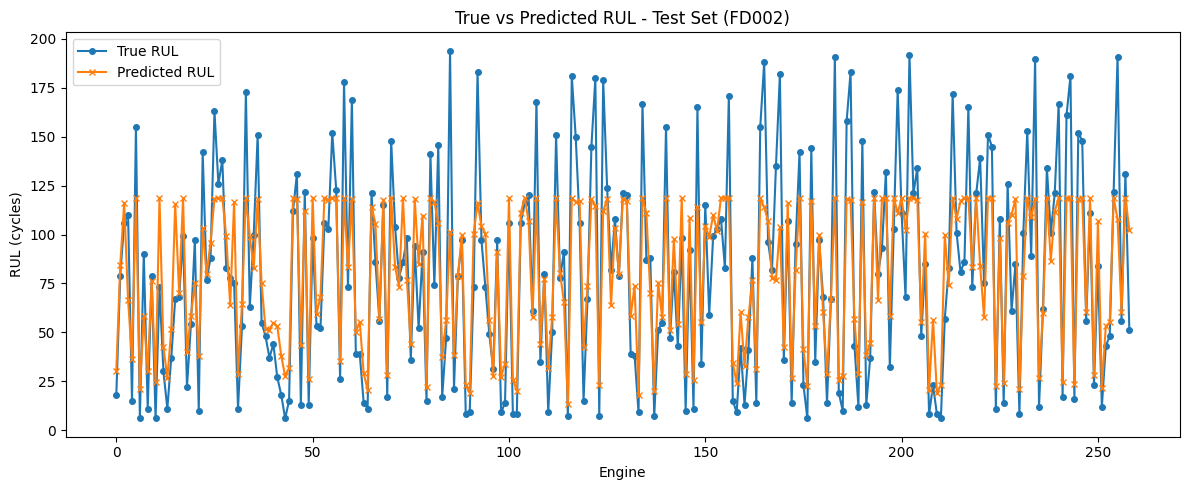

In [ ]:
y_pred = model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test, label='True RUL', marker='o', markersize=4)
plt.plot(y_pred, label='Predicted RUL', marker='x', markersize=4)
plt.xlabel('Engine')
plt.ylabel('RUL (cycles)')
plt.title('True vs Predicted RUL - Test Set (FD002)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/fd002_baseline_rul_predictions.png')
plt.show()

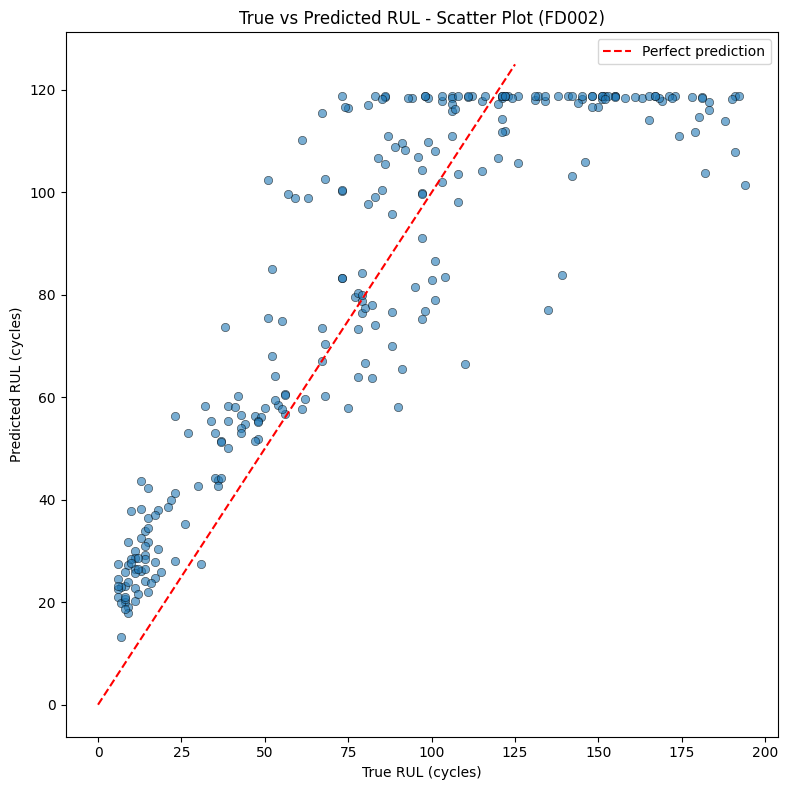

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.plot([0, 125], [0, 125], 'r--', label='Perfect prediction')
plt.xlabel('True RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title('True vs Predicted RUL - Scatter Plot (FD002)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/fd002_rul_scatter_baseline.png')
plt.show()

## (ii) Experiment with Asymmetric MSE Loss and varying hyper-parameters
Experiment to increase percent below line and decrease `RMSE` and `Mean error`. The asymmetric loss function is implemented in `src/models/losses.py`. It penalizes overestimation (positive error) more heavily than underestimation using separate penalty weights `alpha` and `beta`.


* Asymmetric MSE Loss, ` betas=[1.5,2,3,4]`



Training with beta=1.5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step
Beta=1.5 | RMSE=29.15 | Mean Error=-1.52 | % Below Line=38.2% | S-Score=9004.96

Training with beta=2.0...
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step
Beta=2.0 | RMSE=30.13 | Mean Error=1.93 | % Below Line=34.4% | S-Score=8104.04

Training with beta=3.0...
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step
Beta=3.0 | RMSE=29.93 | Mean Error=-6.53 | % Below Line=43.2% | S-Score=11513.94

Training with beta=4.0...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
Beta=4.0 | RMSE=30.81 | Mean Error=-10.12 | % Below Line=54.1% | S-Score=15677.08


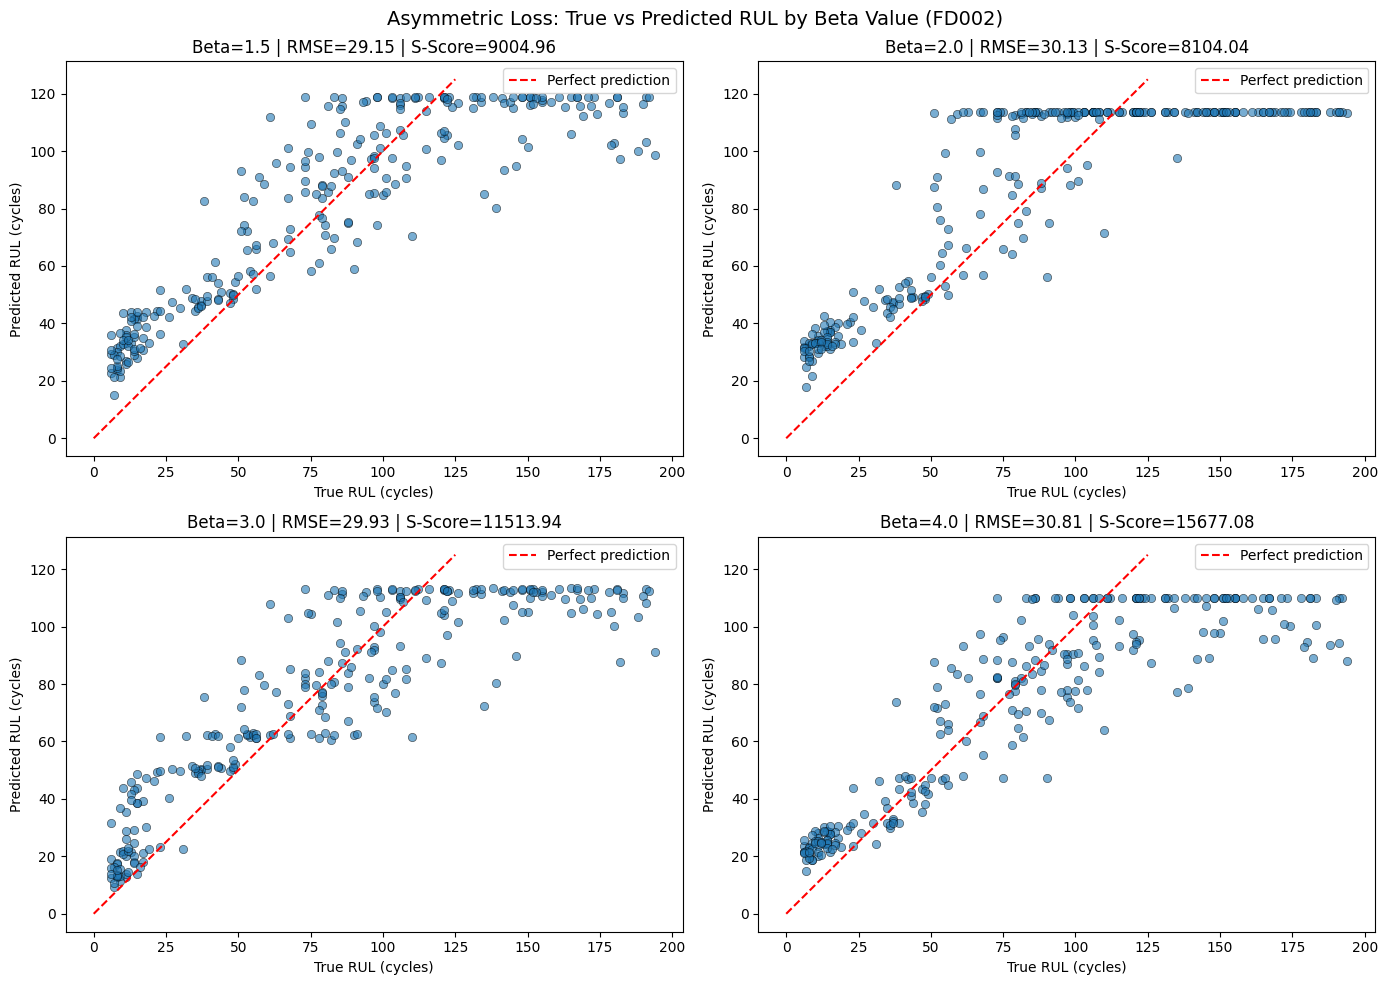


--- Summary ---
Beta       RMSE       Mean Error      % Below Line    S-Score     
1.5        29.15      -1.52           38.2            9004.96     
2.0        30.13      1.93            34.4            8104.04     
3.0        29.93      -6.53           43.2            11513.94    
4.0        30.81      -10.12          54.1            15677.08    


In [ ]:

betas = [1.5, 2.0, 3.0, 4.0]
results = {}
epochs_per_run = 20
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, beta in enumerate(betas):
    print(f"\nTraining with beta={beta}...")
    model_beta = cnn_lstm.CNN_LSTM()
    model_beta.compile(
        loss=make_asymmetric_mse(alpha=1.0, beta=float(beta)),
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['mse']
    )
    history = model_beta.fit(
        X_train, y_train,
        epochs=epochs_per_run,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    y_pred = model_beta.predict(X_test).flatten()

    rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))
    mean_error = np.mean(y_pred - y_test)
    pct_below = np.mean(y_pred < y_test) * 100
    s_score = nasa_s_score(y_test, y_pred)

    results[beta] = {
        'rmse': rmse,
        'mean_error': mean_error,
        'pct_below': pct_below,
        's_score': s_score,
        'y_pred': y_pred
    }

    print(f"Beta={beta} | RMSE={rmse:.2f} | Mean Error={mean_error:.2f} | % Below Line={pct_below:.1f}% | S-Score={s_score:.2f}")

    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.5)
    ax.plot([0, 125], [0, 125], 'r--', label='Perfect prediction')
    ax.set_xlabel('True RUL (cycles)')
    ax.set_ylabel('Predicted RUL (cycles)')
    ax.set_title(f'Beta={beta} | RMSE={rmse:.2f} | S-Score={s_score:.2f}')
    ax.legend()

plt.suptitle('Asymmetric Loss: True vs Predicted RUL by Beta Value (FD002)', fontsize=14)
plt.tight_layout()
plt.savefig('plots/fd002_asymmetric_loss_beta_comparison.png')
plt.show()

# Summary table
print("\n--- Summary ---")
print(f"{'Beta':<10} {'RMSE':<10} {'Mean Error':<15} {'% Below Line':<15} {'S-Score':<12}")
for beta, res in results.items():
    print(f"{beta:<10} {res['rmse']:<10.2f} {res['mean_error']:<15.2f} {res['pct_below']:<15.1f} {res['s_score']:<12.2f}")

In [ ]:
# Summary table
print("\n--- Summary ---")
print(f"{'Beta':<10} {'RMSE':<10} {'Mean Error':<15} {'% Below Line':<15}")
for beta, res in results.items():
    print(f"{beta:<10} {res['rmse']:<10.2f} {res['mean_error']:<15.2f} {res['pct_below']:<15.1f}")

## (iii) Full model training using MSE as a baseline and Asymmetric MSE with best beta, selected from the sweep in experiment (ii). Models are evaluated using the NASA S-Score, an asymmetric evaluation metric standard in PHM literature that penalizes overestimation exponentially more than underestimation. Both loss functions and the S-Score metric are implemented in `src/models/losses.py`.
* MSE
* Asymmetric MSE: `best_beta=2`
* Evaluation Metric: NASA S-Score Loss

In [ ]:
# Experiments
experiments = [
    {
    "name": "asymmetric_mse_beta",
    "loss": make_asymmetric_mse(alpha=1.0, beta=2)
    },
    {
    "name": "baseline_mse",
    "loss": "mse"
    }
]

def run_experiment(experiment, X_train, y_train, X_test, y_test, epochs=50):

    # Instantiate loss
    name = experiment["name"]
    loss = experiment["loss"]
    # Initialize the base architecture
    model = cnn_lstm.CNN_LSTM(input_shape=(30, 18))

    # Check for the pre-trained baseline model
    if name == "baseline_mse":
        print(f"\n[Reloading File] Running evaluation for: {name}")

        # Load weights and compile
        model.load_weights('weights/best_baseline_initial_model_fd002.keras')
        model.compile(
            loss='mse',
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            metrics=['mse']
        )

        # For reloaded models we explicitly set history to None
        history = None

    else:
        print(f"\n[Training Model] Running training loop for: {name}")

        # Build and compile
        model.compile(
            loss=loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            metrics=['mse']
        )

        # Training callbacks setup
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        checkpoint = ModelCheckpoint(
            f'weights/{name}_best.keras',
            monitor='val_loss',
            save_best_only=True
        )

        # Train execution block
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stopping, checkpoint],
            verbose=0
        )

    # Evaluate
    y_pred = model.predict(X_test).flatten()
    rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))
    mean_error = np.mean(y_pred - y_test)
    pct_below = np.mean(y_pred < y_test) * 100

    return {
        "name": name,
        "model": model,
        "history": history,
        "y_pred": y_pred,
        "rmse": rmse,
        "mean_error": mean_error,
        "pct_below": pct_below
    }

# Run all experiments
results = [run_experiment(exp, X_train, y_train, X_test, y_test) for exp in experiments]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[Training Model] Running training loop for: asymmetric_mse_beta



Name                      RMSE       Mean Error      % Below Line    S-Score     
asymmetric_mse_beta       30.39      -5.03           42.1            12912.06    
baseline_mse              27.87      -1.43           38.6            7063.63     


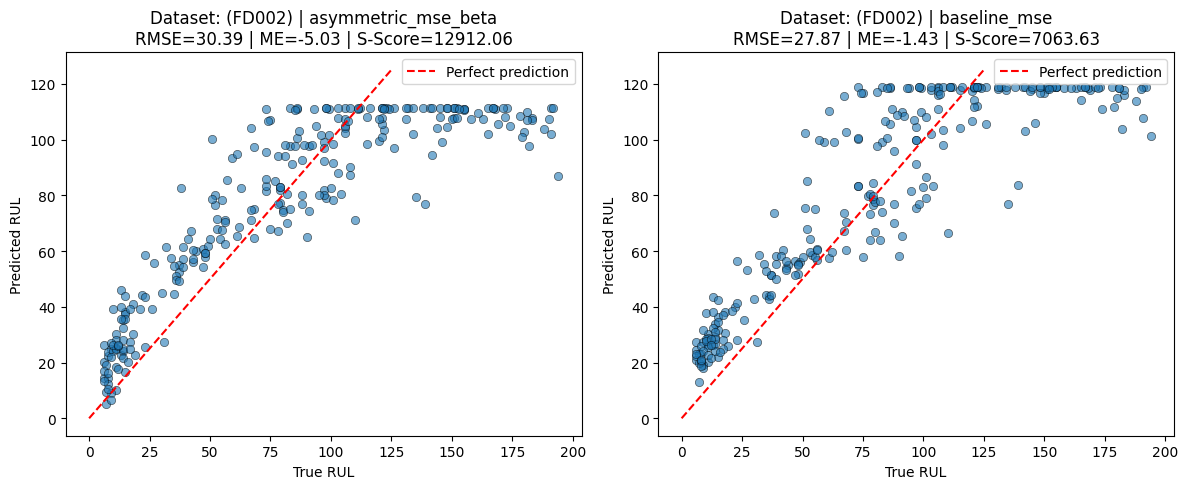

In [ ]:
# Add S-Score to results

DATASET_NAME = "(FD002)"

for r in results:
    r['s_score'] = nasa_s_score(y_test, r['y_pred'])

# Summary table
print(f"\n{'Name':<25} {'RMSE':<10} {'Mean Error':<15} {'% Below Line':<15} {'S-Score':<12}")
for r in results:
    print(f"{r['name']:<25} {r['rmse']:<10.2f} {r['mean_error']:<15.2f} {r['pct_below']:<15.1f} {r['s_score']:<12.2f}")

# Scatter plots with S-Score in title
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
for ax, r in zip(axes, results):
    ax.scatter(y_test, r['y_pred'], alpha=0.6, edgecolors='k', linewidths=0.5)
    ax.plot([0, 125], [0, 125], 'r--', label='Perfect prediction')
    ax.set_title(f"Dataset: {DATASET_NAME} | {r['name']}\nRMSE={r['rmse']:.2f} | ME={r['mean_error']:.2f} | S-Score={r['s_score']:.2f}")
    ax.set_xlabel('True RUL')
    ax.set_ylabel('Predicted RUL')
    ax.legend()
plt.tight_layout()
plt.savefig('plots/fd002_experiment_comparison.png')
plt.show()

# 4. Results and Discussion

### Preprocessing
Raw sensor data from FD002 was inspected for uninformative features within each
of the 6 operating conditions identified via KMeans clustering. Sensors and
operational settings with zero or near-zero variance across all conditions (sensors 1, 5, 16, 18, 19, and op_setting_3) were removed, leaving 18 features. Operating condition labels were used to apply per-condition normalization to remove operating regime variation and isolate degradation signal. RUL labels were capped at 125 cycles and sequences of 30 consecutive cycles were used as input windows. A small number of test engines had fewer than 30 cycles and were front-padded by repeating the earliest available reading to match the required window size.

### (i) Baseline MSE
The CNN-LSTM trained with standard MSE achieved a test RMSE of 27.87 cycles and a mean error of -1.43, indicating a slight underestimation of remaining life, which is a conservative bias. 38.6% of predictions fell below the perfect prediction line.


| Model         | RMSE  | Mean Error | % Below Line | S-Score |
|---------------|------:|-----------:|-------------:|--------:|
| Baseline MSE  | 27.87 | -1.43      | 38.6%        | 7063.63 |


### (ii) Asymmetric MSE with Beta Sweep
The beta parameter controls the penalty weight for overestimation relative to
underestimation. A sweep over beta values [1.5, 2.0, 3.0, 4.0] was conducted over 20 epochs to identify the optimal tradeoff between prediction accuracy (RMSE) and conservative bias (% predictions below the perfect prediction line). The asymmetric loss function is implemented in `src/models/losses.py`. It penalizes overestimation (positive error) more heavily than
underestimation using separate penalty weights alpha and beta.
| Model                        | RMSE  | Mean Error | % Below Line | S-Score  |
|------------------------------|------:|-----------:|-------------:|---------:|
| Asymmetric MSE (beta = 1.5)     | 29.15 | -1.52      | 38.2%        | 9004.96  |
| Asymmetric MSE (beta= 2.0)     | 30.13 | 1.93       | 34.4%        | 8104.04  |
| Asymmetric MSE (beta = 3.0)     | 29.93 | -6.53      | 43.2%        | 11513.94
| Asymmetric MSE (beta = 4.0)     | 30.81 | -10.12     | 54.1%        | 15677.08 |

Beta=2.0 was selected for the full training run.

### (iii) Full Training to Compare Baseline MSE vs Asymmetric MSE (beta=2.0)
A full 50-epoch runs with early stopping was conducted for the asymmetric mse model while the previous weights were loaded for the baseline mse model. The NASA S-Score is used as the primary evaluation metric as it penalizes overestimation exponentially more than underestimation, reflecting the safety-critical nature of maintenance scheduling. The S-Score metric is implemented in `src/models/losses.py`.

| Model | RMSE | Mean Error | % Below Line | S-Score |
|-------|------|------------|--------------|---------|
| Baseline MSE | 27.87 | -1.43 | 38.6% | 7063.63 |
| Asymmetric MSE (beta=2.0) | 30.39 | -5.03 | 42.1% | 12912.06 |

Unlike FD001 where the asymmetric loss successfully optimized the scoring curve, here on FD002 the baseline MSE achieves a substantially better S-Score (7063 vs 12912.06). While the asymmetric loss forces more conservative predictions (42.1% vs 38.6% below the line), it also has a noticeable RMSE increase. The more negative mean error (-5.03 vs. -1.43) indicates a stronger underestimation bias, suggesting that the model is over-shifting toward conservative predictions. However, this shift does not translate into improved S-Score performance, as the overall increase in error magnitude outweighs any benefit from reduced overestimation. These results suggest that beta=2 may be suboptimal for FD002, and more broadly highlight that asymmetric loss functions require careful, dataset-specific tuning, particularly in more complex, multi-condition environments such as FD002.

### Key Takeaways
The baseline MSE achieves a substantially better S-Score (7063 vs 12912.06). The conservative bias observed did not guarantee a better S-Score. Beta=2 introduces excessive underestimation bias showing this level of asymmetry is not well-calibrated for the FD002 dataset. Therefore, the hyperparameters do not transfer across datasets.

The dataset complexity impacts loss effectiveness. The FD002 dataset is more complex than FD001 and required additional pre-processing considerations. A multi-condition operating environment likely makes it more sensitive to bias and error magnitude, reducing the effectiveness of asymmetric loss without additional preprocessing or adjustments.


Note: The NASA S-Score is computed using the standard parameters from Saxena et al. (2008): alpha=13 and beta=10, reflecting the asymmetric operational cost of RUL prediction errors in turbofan engine maintenance.